# Sales Prediction — Data Preprocessing & Feature Engineering

**CodSoft Data Science Internship — Task 4: Sales Prediction Using Python**
(local folder `Task2_Sales_Prediction`, my own project numbering)

**Phase 2 of 3+.** Phase 1 ([`01_dataset_audit.ipynb`](01_dataset_audit.ipynb)) is the source of truth for
the dataset and its findings; this notebook builds on them and does not re-litigate them.

**No model is trained here and no model metric is computed.** The only thing evaluated in this notebook is
the preprocessing itself.

---
## 1. Phase Objective

Establish one reproducible path from the raw CSV to model-ready features, so that Phase 3 training, the
validation folds, the final evaluation, the persisted artefact and any future prediction all see exactly the
same split and exactly the same transformation.

The implementation lives in [`../src/data_preprocessing.py`](../src/data_preprocessing.py) and is *imported*
here rather than repeated. That is the point of this phase: if the preprocessing existed only as notebook
cells, a later phase would have to copy it, and the copies would drift apart.

### Target data flow

```
advertising.csv
      ↓
Raw Data Validation          (schema, dtypes, missing, finite, row count, checksum)
      ↓
Separate X / y               (X = TV, Radio, Newspaper   ·   y = Sales)
      ↓
Train/Test Split             (80 / 20, random_state=42, BEFORE anything is learned)
      ↓
Fit Preprocessor on X_train only
      ↓
Transform X_train
      ↓
Transform X_test             (same fitted object, no refit)
      ↓
Model-ready datasets
      ↓
PHASE 3 MODEL TRAINING
```

The split comes before the fit, not after. That ordering is the whole reason the leakage checks in section 11
can pass.

### What Phase 1 settled, and what follows from it

| Phase 1 finding | Consequence for preprocessing |
|---|---|
| 0 missing cells | no imputation (section 6) |
| 0 duplicate rows / feature combinations | no de-duplication; no risk of a row crossing the split |
| all 4 columns `float64` | no type conversion |
| no categorical, text, ID or date columns | no encoding, no parsing, no column to drop |
| `Sales` skew ≈ −0.07 | no target transformation |
| 2 unusual `Newspaper` budgets | retained — see section 5 |
| no feature derived from the target | no leakage inside the file; only procedural leakage to guard against |

---
## 2. Load and Validate Raw Data

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").is_dir() else NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_DIR / "src"
VIZ_DIR = PROJECT_DIR / "visualizations"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import data_preprocessing as dp

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"

print("project directory :", PROJECT_DIR.name)
print("preprocessing from:", Path(dp.__file__).relative_to(PROJECT_DIR))

project directory : Task2_Sales_Prediction
preprocessing from: src\data_preprocessing.py


### The dataset contract

These constants live in the module, so the notebook, the training phase and the prediction code cannot
disagree about what the columns are or which split was used.

In [2]:
contract = pd.DataFrame(
    [
        ("FEATURE_COLUMNS", str(list(dp.FEATURE_COLUMNS))),
        ("TARGET_COLUMN", dp.TARGET_COLUMN),
        ("EXPECTED_ROWS", str(dp.EXPECTED_ROWS)),
        ("TEST_SIZE", str(dp.TEST_SIZE)),
        ("RANDOM_STATE", str(dp.RANDOM_STATE)),
        ("RAW_DATASET_SHA256", dp.RAW_DATASET_SHA256),
    ],
    columns=["Constant", "Value"],
)
contract

,Constant,Value
0,FEATURE_COLUMNS,"['TV', 'Radio', 'Newspaper']"
1,TARGET_COLUMN,Sales
2,EXPECTED_ROWS,200
3,TEST_SIZE,0.2
4,RANDOM_STATE,42
5,RAW_DATASET_SHA256,137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71ea...


### Load

`load_raw_data()` verifies the checksum, reads the file exactly as it is on disk (no dtype overrides, no
`na_values`, no renaming) and then validates the schema. It raises rather than quietly accepting a file that
does not match the contract.

In [3]:
df = dp.load_raw_data()

print(f"shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"columns: {list(df.columns)}")
print(f"dtypes: {dict(df.dtypes.astype(str))}")
df.head()

shape: 200 rows x 4 columns
columns: ['TV', 'Radio', 'Newspaper', 'Sales']
dtypes: {'TV': 'float64', 'Radio': 'float64', 'Newspaper': 'float64', 'Sales': 'float64'}


,TV,Radio,Newspaper,Sales
0,230.1000,37.8000,69.2000,22.1000
1,44.5000,39.3000,45.1000,10.4000
2,17.2000,45.9000,69.3000,12.0000
3,151.5000,41.3000,58.5000,16.5000
4,180.8000,10.8000,58.4000,17.9000


### The validator actually rejects bad input

A validator that never fails is not evidence of anything. Each case below is fed a deliberately broken frame
and is expected to raise.

In [4]:
def expect_error(label, fn):
    try:
        fn()
    except (ValueError, FileNotFoundError) as exc:
        first_line = str(exc).splitlines()[0]
        print(f"[rejected] {label}\n           -> {first_line}")
        return True
    print(f"[NOT REJECTED] {label}  <-- validation gap")
    return False


results = []

results.append(expect_error(
    "missing expected column (Radio dropped)",
    lambda: dp.validate_raw_dataframe(df.drop(columns=["Radio"])),
))
results.append(expect_error(
    "unexpected extra column",
    lambda: dp.validate_raw_dataframe(df.assign(Unexpected=1.0)),
))
results.append(expect_error(
    "target column absent",
    lambda: dp.validate_raw_dataframe(df.drop(columns=["Sales"])),
))
results.append(expect_error(
    "non-numeric column",
    lambda: dp.validate_raw_dataframe(df.assign(TV=df["TV"].astype(str))),
))
results.append(expect_error(
    "missing value introduced",
    lambda: dp.validate_raw_dataframe(df.assign(TV=df["TV"].mask(df.index == 0))),
))
results.append(expect_error(
    "infinite value introduced",
    lambda: dp.validate_raw_dataframe(df.assign(TV=df["TV"].mask(df.index == 0, np.inf))),
))
results.append(expect_error(
    "wrong row count",
    lambda: dp.validate_raw_dataframe(df.head(10)),
))
results.append(expect_error(
    "target present in a feature matrix",
    lambda: dp.validate_features(df, context="X"),
))
results.append(expect_error(
    "dataset file absent",
    lambda: dp.load_raw_data(PROJECT_DIR / "dataset" / "does_not_exist.csv"),
))

print()
print(f"validation cases rejected as expected: {sum(results)} / {len(results)}")
assert all(results), "A validation case was not rejected."

[rejected] missing expected column (Radio dropped)
           -> Raw dataset is missing expected column(s): ['Radio']. Expected exactly ['TV', 'Radio', 'Newspaper', 'Sales'], found ['TV', 'Newspaper', 'Sales'].
[rejected] unexpected extra column
           -> Raw dataset contains unexpected column(s): ['Unexpected']. Expected exactly ['TV', 'Radio', 'Newspaper', 'Sales'].
[rejected] target column absent
           -> Raw dataset is missing expected column(s): ['Sales']. Expected exactly ['TV', 'Radio', 'Newspaper', 'Sales'], found ['TV', 'Radio', 'Newspaper'].
[rejected] non-numeric column
           -> Column(s) expected to be numeric are not: ['TV'].
[rejected] missing value introduced
           -> Raw dataset contains missing values, which contradicts the Phase 1 audit:
[rejected] infinite value introduced
           -> Raw dataset contains non-finite values (inf / -inf): {'TV': 1}.
[rejected] wrong row count
           -> Raw dataset has 10 rows, expected 200. The raw file may hav

**Result.** All nine cases raise a clear, specific error. The real file passes the same validator, so the
checks above are meaningful rather than decorative.

Note the fifth and sixth cases: a missing or infinite value is *reported*, not silently repaired. The
reasoning is in section 6.

---
## 3. Separate Features and Target

`X` is built by selecting `FEATURE_COLUMNS` explicitly, in a fixed order. The target cannot be included by
accident, and no column can arrive in a different position between training and prediction.

In [5]:
X, y = dp.split_features_target(df)

print("X shape:", X.shape, "| columns:", list(X.columns))
print("y name :", y.name, "| length:", len(y))
print()
print("target excluded from X   :", dp.TARGET_COLUMN not in X.columns)
print("X columns exactly as spec:", tuple(X.columns) == dp.FEATURE_COLUMNS)
print("row counts aligned       :", len(X) == len(y) == dp.EXPECTED_ROWS)
X.head(3)

X shape: (200, 3) | columns: ['TV', 'Radio', 'Newspaper']
y name : Sales | length: 200

target excluded from X   : True
X columns exactly as spec: True
row counts aligned       : True


,TV,Radio,Newspaper
0,230.1000,37.8000,69.2000
1,44.5000,39.3000,45.1000
2,17.2000,45.9000,69.3000


**No feature is derived from `Sales`.** The three predictors are the raw advertising budgets and nothing
else. No ratio, share, rank or aggregate of the target exists anywhere in the pipeline — that would be
textbook target leakage, and the check in section 11 confirms it is absent.

**No feature engineering was added.** With three clean numeric predictors and 200 rows, inventing derived
columns before there is any evidence that they help would add variance and complexity for nothing. If an
interaction such as `TV × Radio` turns out to be warranted, that is a modelling hypothesis to be tested
against validation performance in Phase 3, not an assumption to bake in here.

---
## 4. Train/Test Split

80 / 20, `random_state=42`, performed **before** anything is fitted.

The data is cross-sectional — Phase 1 found no date, order or group column — so a plain random split is the
right choice: there is no chronology to respect and no group that could span both sides. Stratification does
not apply to a continuous target.

In [6]:
split = dp.make_train_test_split(X, y, test_size=dp.TEST_SIZE, random_state=dp.RANDOM_STATE)

print(f"random_state : {split.random_state}")
print(f"test_size    : {split.test_size}")
print(f"X_train      : {split.X_train.shape}")
print(f"X_test       : {split.X_test.shape}")
print(f"y_train      : {split.y_train.shape}")
print(f"y_test       : {split.y_test.shape}")
split.summary()

random_state : 42
test_size    : 0.2
X_train      : (160, 3)
X_test       : (40, 3)
y_train      : (160,)
y_test       : (40,)


,Split,Rows,Share
0,train,160,0.8000
1,test,40,0.2000
2,total,200,1.0000


In [7]:
assert split.n_train + split.n_test == dp.EXPECTED_ROWS, "Split does not cover all 200 rows."
assert split.n_train == 160 and split.n_test == 40, "Unexpected split sizes."
assert tuple(split.X_train.columns) == tuple(split.X_test.columns), "Predictor columns differ."
assert split.X_train.index.intersection(split.X_test.index).empty, "A row appears in both splits."
assert split.X_train.index.equals(split.y_train.index), "X_train / y_train indices are misaligned."
assert split.X_test.index.equals(split.y_test.index), "X_test / y_test indices are misaligned."

print("len(X_train) + len(X_test) ==", split.n_train + split.n_test, "== 200")
print("identical predictor columns:", list(split.X_train.columns))
print("no row shared between train and test:", split.X_train.index.intersection(split.X_test.index).empty)
print("X / y index alignment holds on both sides")

len(X_train) + len(X_test) == 200 == 200
identical predictor columns: ['TV', 'Radio', 'Newspaper']
no row shared between train and test: True
X / y index alignment holds on both sides


**Result.** 160 training rows and 40 test rows, summing to exactly 200, with no row on both sides and `X`
and `y` aligned on both. The predictor columns are identical in name and order across the two.

From this point on, the 40 test rows are set aside. They are not looked at, summarised or fitted on for the
rest of the phase, other than being transformed by the already-fitted preprocessor in section 9.

---
## 5. Outlier Handling Decision

Phase 1 flagged exactly two rows as unusual, both high `Newspaper` budgets. The decision recorded in the
module is to **keep all 200 observations**.

In [8]:
print(dp.OUTLIER_DECISION)

All 200 observations are retained. Phase 1 flagged exactly two rows (1.0%) as unusual, both of them high Newspaper budgets (114.0 and 100.9). They are statistically unusual, not invalid: both sit in a realistic range for an advertising budget, neither is negative, a sentinel code or a duplicate, and nothing in the data indicates a recording error. Statistical unusualness alone is not evidence that an observation is wrong, and with only 200 rows, discarding real data costs more than it gains. They are therefore neither dropped, winsorised, clipped nor replaced. Whether they exert undue influence on a fitted model is a question for model diagnostics in a later phase, not a preprocessing decision.


In [9]:
q1, q3 = df["Newspaper"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
flagged = df[df["Newspaper"] > upper]

print(f"Newspaper IQR upper bound: {upper:.4f}")
print(f"rows above it            : {len(flagged)}  ({len(flagged) / len(df) * 100:.1f}% of the dataset)")
display(flagged)

in_train = flagged.index.intersection(split.X_train.index)
in_test = flagged.index.intersection(split.X_test.index)
print(f"of those rows, {len(in_train)} fell in the training set and {len(in_test)} in the test set")
print(f"rows retained overall: {len(split.X_train) + len(split.X_test)} of {dp.EXPECTED_ROWS}")

Newspaper IQR upper bound: 93.6250
rows above it            : 2  (1.0% of the dataset)


,TV,Radio,Newspaper,Sales
16,67.8000,36.6000,114.0000,12.5000
101,296.4000,36.3000,100.9000,23.8000


of those rows, 1 fell in the training set and 1 in the test set
rows retained overall: 200 of 200


**Decision: retained. Not dropped, not winsorised, not clipped, not replaced.**

Both values are plausible advertising budgets, and the corresponding `Sales` figures (12.5 and 23.8) sit
comfortably inside the normal range of the target — these are not wild records. Removing a real observation
because it is unusual is a decision that needs evidence of an error, and there is none: no negative value, no
sentinel code, no duplicate, no impossible magnitude. With 200 rows in total, throwing away 1% of the
evidence to make a box plot look tidier is a poor trade.

Whether these two rows exert disproportionate influence on a *fitted* model is a different question, and it
belongs to model diagnostics in Phase 3 (e.g. Cook's distance on a linear fit), where it can be measured
rather than assumed.

The two flagged rows happened to land one in the training set and one in the test set. That is a
consequence of the fixed seed, not a choice — nothing was done to arrange it, and neither row was moved or
excluded to make the split tidier.

---
## 6. Missing Value Assessment

In [10]:
missing = pd.DataFrame({
    "Missing (raw)": df.isna().sum(),
    "Missing (X_train)": split.X_train.isna().sum().reindex(df.columns).fillna(0).astype(int),
    "Missing (X_test)": split.X_test.isna().sum().reindex(df.columns).fillna(0).astype(int),
})
display(missing)

print("total missing cells in the raw file:", int(df.isna().sum().sum()))
print("all raw values finite             :", bool(np.isfinite(df.to_numpy(dtype=float)).all()))

,Missing (raw),Missing (X_train),Missing (X_test)
TV,0,0,0
Radio,0,0,0
Newspaper,0,0,0
Sales,0,0,0


total missing cells in the raw file: 0
all raw values finite             : True


**Decision: no imputer.**

The dataset contains zero missing predictor values, so an imputer would fit a statistic that is never
applied — it would transform nothing today. That alone would be harmless. What is *not* harmless is its
behaviour later: at prediction time, a `SimpleImputer` would quietly substitute the training mean for a
genuinely absent input and return a confident-looking number, hiding a real data problem from whoever is
relying on the prediction.

The preprocessing instead **validates and raises**. `validate_features()` rejects missing and non-finite
input with a message naming the offending columns (demonstrated in section 2). A missing advertising budget
is a fact worth surfacing, not a gap worth papering over.

This is the simplest defensible choice: nothing is fabricated to justify a component, and robustness is
handled by detection rather than by silent substitution. If a future data source genuinely arrives with
missing budgets, adding an imputer to the numeric pipeline in `build_preprocessor()` is a one-line change —
made then, with the real missingness pattern in view, rather than guessed at now.

---
## 7. Preprocessing Pipeline

Architecture:

```
ColumnTransformer
  └── "numeric"  →  Pipeline([("scaler", StandardScaler())])   on  ["TV", "Radio", "Newspaper"]
      remainder = "drop"
```

A `ColumnTransformer` keyed on explicit column *names* is used even though all three predictors are numeric.
It pins the transformation to names rather than positions, so a caller that supplies the columns in a
different order — or supplies an extra column — is rejected instead of silently mis-transformed. With
`remainder="drop"`, nothing outside the three declared features can reach a model even if it is passed in.

In [11]:
preprocessor = dp.build_preprocessor(scale=True)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of

### Why standardisation, given that it is not always needed

Phase 3 compares model families with different requirements, and one shared pipeline is safer than two
competing ones:

| Model family | Needs scaling? | Effect of scaling here |
|---|---|---|
| Ordinary least squares | no | none — fitted values and every metric are identical either way |
| Ridge / Lasso / ElasticNet | **yes** | the penalty is applied comparably across predictors |
| KNN / SVR (distance-based) | **yes** | distances are not dominated by the largest-range column |
| Decision tree / Random Forest / Gradient Boosting | no | none — these are invariant to a monotone rescaling |

The scale disparity is real: `TV` spans 0.7–296.4 while `Radio` spans 0.0–49.6. Without standardisation a
regularisation penalty would fall far more heavily on the `Radio` coefficient than on the `TV` coefficient,
purely because of the units the budgets happen to be recorded in.

Since scaling is *required* by some candidates and *inert* for the rest, standardising once and sharing that
pipeline costs nothing and removes an entire category of mistake — the kind where two preprocessing paths
drift apart and models end up compared on different data. `build_preprocessor(scale=False)` exists for a
deliberate like-for-like comparison, but the project default is `scale=True`.

`StandardScaler` learns exactly two numbers per column, a mean and a standard deviation. It is a per-column
linear map, so it cannot mix information across rows or across columns — which is what makes the leakage
question in section 11 a simple, checkable one.

---
## 8. Fit on Training Data

The preprocessor is fitted on `X_train` and on nothing else.

In [12]:
preprocessor.fit(split.X_train)

scaler = preprocessor.named_transformers_["numeric"].named_steps["scaler"]
feature_names = dp.get_feature_names(preprocessor)

print("fitted on:", split.X_train.shape[0], "training rows")
print("output feature names:", feature_names)
print(f"n_features_in_: {scaler.n_features_in_}  |  n_samples_seen_: {scaler.n_samples_seen_}")

fitted on: 160 training rows
output feature names: ['TV', 'Radio', 'Newspaper']
n_features_in_: 3  |  n_samples_seen_: 160.0


In [13]:
learned = pd.DataFrame({
    "scaler mean_": scaler.mean_,
    "X_train mean": split.X_train.mean().to_numpy(),
    "scaler scale_": scaler.scale_,
    "X_train std (population)": split.X_train.std(ddof=0).to_numpy(),
}, index=feature_names)
learned

,scaler mean_,X_train mean,scaler scale_,X_train std (population)
TV,150.0194,150.0194,84.1546,84.1546
Radio,22.8756,22.8756,14.7589,14.7589
Newspaper,29.9456,29.9456,20.2728,20.2728


**Result.** The learned `mean_` and `scale_` reproduce the training-set mean and population standard
deviation exactly, which is what `StandardScaler` is defined to do. `n_samples_seen_` is 160 — the scaler saw
the 160 training rows and no others.

Section 11 checks the thing that actually matters: that these numbers differ from the full-dataset
statistics.

---
## 9. Transform Train and Test Data

Both matrices are produced by the **same already-fitted object**. `transform_features()` only ever calls
`transform`; it never calls `fit` or `fit_transform`, so applying it to the test set cannot update a single
learned parameter.

In [14]:
X_train_prepared = dp.transform_features(preprocessor, split.X_train, context="X_train")
X_test_prepared = dp.transform_features(preprocessor, split.X_test, context="X_test")

print("X_train_prepared:", X_train_prepared.shape)
print("X_test_prepared :", X_test_prepared.shape)
print("feature names   :", list(X_train_prepared.columns))
X_train_prepared.head()

X_train_prepared: (160, 3)
X_test_prepared : (40, 3)
feature names   : ['TV', 'Radio', 'Newspaper']


,TV,Radio,Newspaper
79,-0.4042,-1.0282,-0.3377
197,0.3206,-0.9198,-1.1614
38,-1.2705,0.2591,0.2543
24,-1.0424,-0.6962,-0.5744
122,0.8791,-1.3873,-0.7076


---
## 10. Preprocessing Validation

In [15]:
checks = []


def check(label, condition, detail=""):
    checks.append({"Check": label, "Passed": bool(condition), "Detail": detail})
    return bool(condition)


check("raw row count is 200", len(df) == 200, f"{len(df)} rows")
check("raw column count is 4", df.shape[1] == 4, f"{df.shape[1]} columns")
check("target is Sales", dp.TARGET_COLUMN == "Sales", dp.TARGET_COLUMN)
check("predictors are TV / Radio / Newspaper",
      tuple(X.columns) == ("TV", "Radio", "Newspaper"), str(list(X.columns)))
check("target excluded from X", dp.TARGET_COLUMN not in X.columns)
check("train/test split is 80/20",
      split.n_train == 160 and split.n_test == 40, f"{split.n_train} / {split.n_test}")
check("split covers every row", split.n_train + split.n_test == 200)
check("random_state is 42", split.random_state == 42, str(split.random_state))
check("all 200 observations retained (no outlier removal)",
      split.n_train + split.n_test == len(df))
check("X_train and X_test share identical columns",
      list(split.X_train.columns) == list(split.X_test.columns))
check("transformed feature count is 3",
      X_train_prepared.shape[1] == 3 and X_test_prepared.shape[1] == 3,
      f"{X_train_prepared.shape[1]} features")
check("transformed feature names preserved",
      list(X_train_prepared.columns) == list(dp.FEATURE_COLUMNS))
check("transformed row counts match the split",
      len(X_train_prepared) == split.n_train and len(X_test_prepared) == split.n_test)
check("no missing values after transformation",
      int(X_train_prepared.isna().sum().sum()) + int(X_test_prepared.isna().sum().sum()) == 0)
check("all transformed values finite",
      bool(np.isfinite(X_train_prepared.to_numpy()).all() and np.isfinite(X_test_prepared.to_numpy()).all()))
check("target absent from transformed matrices",
      dp.TARGET_COLUMN not in X_train_prepared.columns and dp.TARGET_COLUMN not in X_test_prepared.columns)
check("transformed indices align with y",
      X_train_prepared.index.equals(split.y_train.index) and X_test_prepared.index.equals(split.y_test.index))

results_df = pd.DataFrame(checks)
display(results_df)
print(f"\npassed {int(results_df['Passed'].sum())} / {len(results_df)} checks")
assert results_df["Passed"].all(), "A preprocessing validation check failed."

,Check,Passed,Detail
0,raw row count is 200,True,200 rows
1,raw column count is 4,True,4 columns
2,target is Sales,True,Sales
3,predictors are TV / Radio / Newspaper,True,"['TV', 'Radio', 'Newspaper']"
4,target excluded from X,True,
5,train/test split is 80/20,True,160 / 40
6,split covers every row,True,
7,random_state is 42,True,42
8,all 200 observations retained (no outlier remo...,True,
9,X_train and X_test share identical columns,True,



passed 17 / 17 checks


In [16]:
summary = pd.concat(
    [
        split.X_train.describe().T.add_prefix("raw "),
        X_train_prepared.describe().T.add_prefix("scaled "),
    ],
    axis=1,
)[["raw mean", "raw std", "raw min", "raw max", "scaled mean", "scaled std", "scaled min", "scaled max"]]
summary

,raw mean,raw std,raw min,raw max,scaled mean,scaled std,scaled min,scaled max
TV,150.0194,84.4189,0.7000,296.4000,-0.0000,1.0031,-1.7743,1.7394
Radio,22.8756,14.8052,0.0000,49.6000,-0.0000,1.0031,-1.5500,1.8107
Newspaper,29.9456,20.3364,0.3000,100.9000,0.0000,1.0031,-1.4623,3.5000


**Result.** All 17 checks pass. The transformation keeps three features with their original names, produces
no missing or infinite value, and preserves the row index so every transformed row still lines up with its
`Sales` value.

The before/after table shows what standardisation actually did: three columns whose raw ranges differ by a
factor of roughly six are now on a common scale, each centred on 0 **on the training set**. The table reports
`scaled std` as 1.0031 rather than 1.000 because `describe()` uses the sample standard deviation (`ddof=1`)
while `StandardScaler` divides by the population one (`ddof=0`); on 160 rows the two differ by a factor of
√(160/159). The population standard deviation of each scaled column is exactly 1, as section 11.3 shows.

The *shape* of each distribution is unchanged — standardisation is a linear shift and rescale, not a
transformation of the distribution.

### Preprocessing effect

One chart, showing the only thing worth seeing here: the raw columns sit on incomparable scales, and after
standardisation they do not.

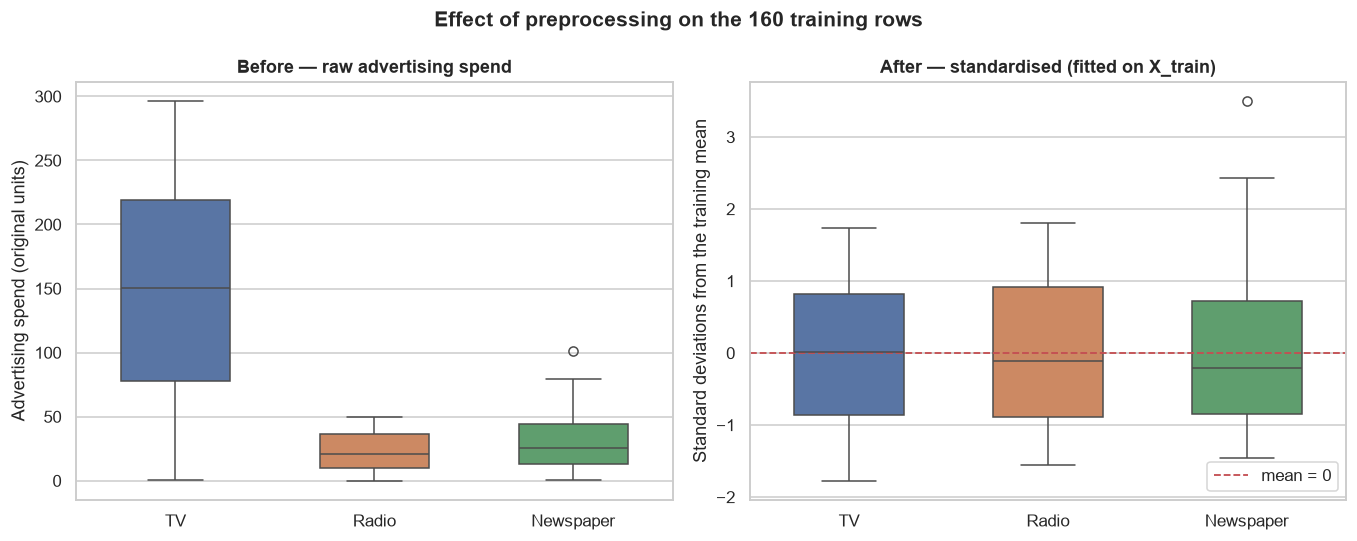

In [17]:
raw_long = split.X_train.melt(var_name="Feature", value_name="Value")
scaled_long = X_train_prepared.melt(var_name="Feature", value_name="Value")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

sns.boxplot(data=raw_long, x="Feature", y="Value", ax=axes[0], width=0.55, palette="deep", hue="Feature",
            legend=False)
axes[0].set_title("Before — raw advertising spend")
axes[0].set_ylabel("Advertising spend (original units)")
axes[0].set_xlabel("")

sns.boxplot(data=scaled_long, x="Feature", y="Value", ax=axes[1], width=0.55, palette="deep", hue="Feature",
            legend=False)
axes[1].axhline(0, color="#C44E52", linestyle="--", linewidth=1.2, label="mean = 0")
axes[1].set_title("After — standardised (fitted on X_train)")
axes[1].set_ylabel("Standard deviations from the training mean")
axes[1].set_xlabel("")
axes[1].legend(loc="lower right")

fig.suptitle("Effect of preprocessing on the 160 training rows", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "05_preprocessing_effect.png")
plt.show()

**Reading the chart.** On the left the three budgets are not comparable: `TV`'s box alone spans a wider range
than the entire `Radio` column. On the right all three are centred on 0 with unit standard deviation, so a
regularisation penalty applies to each on equal terms.

The retained `Newspaper` outlier that fell in the training set (the other one landed in the test set) is
still plotted as a flier on **both** panels — as it should be, since nothing was removed. Standardisation
shifts and rescales the axis; it does not delete or compress extreme observations. On the raw panel it sits
at a spend of 100.9; on the scaled panel it sits at 3.5 training standard deviations above the mean. Same
observation, same relative position, different units.

---
## 11. Leakage Checks

This is the section that justifies the ordering of the whole pipeline. Four distinct things are checked.

### 11.1 The scaler's parameters come from the training rows only

If the preprocessor had been fitted on all 200 rows, its `mean_` would equal the full-dataset mean. It does
not — it equals the 160-row training mean, and the two are measurably different.

In [18]:
full_mean = X.mean().to_numpy()
full_std = X.std(ddof=0).to_numpy()
train_mean = split.X_train.mean().to_numpy()
train_std = split.X_train.std(ddof=0).to_numpy()

comparison = pd.DataFrame({
    "scaler mean_": scaler.mean_,
    "train mean (160)": train_mean,
    "FULL mean (200)": full_mean,
    "scaler scale_": scaler.scale_,
    "train std (160)": train_std,
    "FULL std (200)": full_std,
}, index=feature_names)
display(comparison)

matches_train = np.allclose(scaler.mean_, train_mean) and np.allclose(scaler.scale_, train_std)
matches_full = np.allclose(scaler.mean_, full_mean) and np.allclose(scaler.scale_, full_std)

print("scaler parameters match TRAINING-only statistics :", matches_train)
print("scaler parameters match FULL-dataset statistics  :", matches_full, "(must be False)")
assert matches_train, "Scaler was not fitted on the training statistics."
assert not matches_full, "LEAKAGE: scaler statistics match the full dataset."

,scaler mean_,train mean (160),FULL mean (200),scaler scale_,train std (160),FULL std (200)
TV,150.0194,150.0194,147.0425,84.1546,84.1546,85.6393
Radio,22.8756,22.8756,23.2640,14.7589,14.7589,14.8096
Newspaper,29.9456,29.9456,30.5540,20.2728,20.2728,21.7241


scaler parameters match TRAINING-only statistics : True
scaler parameters match FULL-dataset statistics  : False (must be False)


### 11.2 Transforming the test set does not refit anything

The learned parameters are recorded, the test set is transformed, and the parameters are compared again. A
transformer that refitted on test data would change here.

In [19]:
mean_before = scaler.mean_.copy()
scale_before = scaler.scale_.copy()
n_seen_before = int(scaler.n_samples_seen_)

_ = dp.transform_features(preprocessor, split.X_test, context="X_test")
_ = dp.transform_features(preprocessor, split.X_test, context="X_test")  # again, for good measure

scaler_after = preprocessor.named_transformers_["numeric"].named_steps["scaler"]

unchanged = (
    np.array_equal(mean_before, scaler_after.mean_)
    and np.array_equal(scale_before, scaler_after.scale_)
    and n_seen_before == int(scaler_after.n_samples_seen_)
)
print("mean_ unchanged after transforming test data :", np.array_equal(mean_before, scaler_after.mean_))
print("scale_ unchanged after transforming test data:", np.array_equal(scale_before, scaler_after.scale_))
print(f"n_samples_seen_ still {int(scaler_after.n_samples_seen_)} (training rows only)")
assert unchanged, "LEAKAGE: transforming the test set altered the fitted parameters."

mean_ unchanged after transforming test data : True
scale_ unchanged after transforming test data: True
n_samples_seen_ still 160 (training rows only)


### 11.3 The transformed test set is *not* centred on zero

This is the most direct evidence that the test rows played no part in the fit. If the scaler had seen them,
their transformed mean would be ~0 and their standard deviation ~1. Instead they are merely *close* to that —
which is exactly what an unseen sample from the same population should look like.

In [20]:
test_stats = pd.DataFrame({
    "X_train_prepared mean": X_train_prepared.mean(),
    "X_train_prepared std": X_train_prepared.std(ddof=0),
    "X_test_prepared mean": X_test_prepared.mean(),
    "X_test_prepared std": X_test_prepared.std(ddof=0),
})
display(test_stats)

train_centred = np.allclose(X_train_prepared.mean().to_numpy(), 0, atol=1e-12)
test_exactly_centred = np.allclose(X_test_prepared.mean().to_numpy(), 0, atol=1e-12)

print("training set transformed to mean 0 :", train_centred, "(expected True)")
print("test set exactly centred on mean 0 :", test_exactly_centred, "(expected False — it was never fitted)")
assert train_centred, "Training set is not centred; the scaler was not fitted on it."
assert not test_exactly_centred, "LEAKAGE: test set is exactly centred, implying it was part of the fit."

,X_train_prepared mean,X_train_prepared std,X_test_prepared mean,X_test_prepared std
TV,-0.0000,1.0000,-0.1769,1.0738
Radio,-0.0000,1.0000,0.1316,1.0103
Newspaper,0.0000,1.0000,0.1500,1.3128


training set transformed to mean 0 : True (expected True)
test set exactly centred on mean 0 : False (expected False — it was never fitted)


### 11.4 No feature is derived from the target, and nothing else can reach the model

Re-verified here rather than assumed from Phase 1.

In [21]:
leak_checks = pd.DataFrame([
    {"Leakage risk": "target present in X", "Present": dp.TARGET_COLUMN in X.columns},
    {"Leakage risk": "target present in transformed train",
     "Present": dp.TARGET_COLUMN in X_train_prepared.columns},
    {"Leakage risk": "target present in transformed test",
     "Present": dp.TARGET_COLUMN in X_test_prepared.columns},
    {"Leakage risk": "a predictor is a deterministic function of Sales",
     "Present": any(abs(df[c].corr(df[dp.TARGET_COLUMN])) > 0.98 for c in dp.FEATURE_COLUMNS)},
    {"Leakage risk": "a predictor has a constant ratio to Sales",
     "Present": any(np.isclose((df[c] / df[dp.TARGET_COLUMN]).std(), 0) for c in dp.FEATURE_COLUMNS)},
    {"Leakage risk": "row shared between train and test",
     "Present": not split.X_train.index.intersection(split.X_test.index).empty},
    {"Leakage risk": "duplicate rows that could cross the split",
     "Present": bool(df.duplicated().any())},
    {"Leakage risk": "preprocessing fitted on the full dataset", "Present": matches_full},
    {"Leakage risk": "column outside FEATURE_COLUMNS reaches the model",
     "Present": set(X_train_prepared.columns) - set(dp.FEATURE_COLUMNS) != set()},
])
display(leak_checks)

print("\nany leakage risk present:", bool(leak_checks["Present"].any()), "(must be False)")
assert not leak_checks["Present"].any(), "A leakage risk is present."

,Leakage risk,Present
0,target present in X,False
1,target present in transformed train,False
2,target present in transformed test,False
3,a predictor is a deterministic function of Sales,False
4,a predictor has a constant ratio to Sales,False
5,row shared between train and test,False
6,duplicate rows that could cross the split,False
7,preprocessing fitted on the full dataset,False
8,column outside FEATURE_COLUMNS reaches the model,False



any leakage risk present: False (must be False)


In [22]:
extra = X.assign(Sales=y, Unexpected=1.0)
try:
    dp.transform_features(preprocessor, extra, context="X_with_extras")
    print("[NOT REJECTED] a frame containing Sales was transformed  <-- leakage gap")
except ValueError as exc:
    print("[rejected] frame containing Sales and an extra column")
    print("           ->", str(exc).splitlines()[0])

[rejected] frame containing Sales and an extra column
           -> X_with_extras must not contain the target column 'Sales'.


**Leakage results — all four checks pass.**

1. The scaler's `mean_` is `[150.02, 22.88, 29.95]`, the *training* mean. The full-dataset mean is
   `[147.04, 23.26, 30.55]`. They differ, so the fit demonstrably excluded the test rows.
2. Transforming the test set twice left `mean_`, `scale_` and `n_samples_seen_` byte-identical.
   `n_samples_seen_` remains 160.
3. The transformed training set is centred on exactly 0; the transformed test set is *not* — its means are
   around −0.18, 0.13 and 0.15. An unseen sample should be near zero but not at it, and it is.
4. No predictor is a function of the target, no row is shared between the splits, and a frame containing
   `Sales` is rejected outright rather than silently transformed.

The remaining leakage risk is procedural and belongs to Phase 3: cross-validation must fit the preprocessor
**inside** each fold, not once on all of `X_train`. Because the preprocessing is a `ColumnTransformer`, it can
be composed into a `Pipeline` with an estimator and handed to `cross_val_score`, which refits it per fold
automatically. That is the intended usage.

---
## 12. Reproducibility Checks

Later phases must reproduce this exact split, or the "held-out" test set is not held out in any meaningful
sense — a model selected against one split and reported on another is not being evaluated honestly.

In [23]:
split_a = dp.make_train_test_split(X, y, test_size=dp.TEST_SIZE, random_state=dp.RANDOM_STATE)
split_b = dp.make_train_test_split(X, y, test_size=dp.TEST_SIZE, random_state=dp.RANDOM_STATE)

repro = pd.DataFrame([
    {"Component": "X_train", "Identical": split_a.X_train.equals(split_b.X_train)},
    {"Component": "X_test", "Identical": split_a.X_test.equals(split_b.X_test)},
    {"Component": "y_train", "Identical": split_a.y_train.equals(split_b.y_train)},
    {"Component": "y_test", "Identical": split_a.y_test.equals(split_b.y_test)},
    {"Component": "X_train index order", "Identical": split_a.X_train.index.equals(split_b.X_train.index)},
    {"Component": "X_test index order", "Identical": split_a.X_test.index.equals(split_b.X_test.index)},
    {"Component": "matches the split used above",
     "Identical": split_a.X_train.equals(split.X_train) and split_a.y_test.equals(split.y_test)},
])
display(repro)

assert repro["Identical"].all(), "The split is not reproducible."
print("\nevery component identical across repeated calls with random_state=42")
print("first 10 test-set indices:", list(split_a.X_test.index[:10]))

,Component,Identical
0,X_train,True
1,X_test,True
2,y_train,True
3,y_test,True
4,X_train index order,True
5,X_test index order,True
6,matches the split used above,True



every component identical across repeated calls with random_state=42
first 10 test-set indices: [95, 15, 30, 158, 128, 115, 69, 170, 174, 45]


### A different seed gives a different split

A sanity check in the other direction: if the seed did not matter, the check above would be meaningless.

In [24]:
split_other = dp.make_train_test_split(X, y, test_size=dp.TEST_SIZE, random_state=7)
print("random_state=7 produces the same test rows as 42:",
      split_other.X_test.index.equals(split.X_test.index), "(expected False)")
print("overlap between the two test sets:",
      len(split_other.X_test.index.intersection(split.X_test.index)), "of 40 rows")
assert not split_other.X_test.index.equals(split.X_test.index)

random_state=7 produces the same test rows as 42: False (expected False)
overlap between the two test sets: 6 of 40 rows


### The full pipeline is reproducible end to end

`prepare_modeling_data()` is what Phase 3 will call. Running it twice must give byte-identical results, and
those must match everything built step by step in this notebook.

In [25]:
md_a = dp.prepare_modeling_data()
md_b = dp.prepare_modeling_data()

pipeline_repro = pd.DataFrame([
    {"Component": "X_train_prepared", "Identical": md_a.X_train_prepared.equals(md_b.X_train_prepared)},
    {"Component": "X_test_prepared", "Identical": md_a.X_test_prepared.equals(md_b.X_test_prepared)},
    {"Component": "y_train", "Identical": md_a.y_train.equals(md_b.y_train)},
    {"Component": "y_test", "Identical": md_a.y_test.equals(md_b.y_test)},
    {"Component": "scaler mean_", "Identical": np.array_equal(
        md_a.preprocessor.named_transformers_["numeric"].named_steps["scaler"].mean_,
        md_b.preprocessor.named_transformers_["numeric"].named_steps["scaler"].mean_)},
    {"Component": "matches this notebook's step-by-step result",
     "Identical": md_a.X_train_prepared.equals(X_train_prepared)
                  and md_a.X_test_prepared.equals(X_test_prepared)},
])
display(pipeline_repro)

assert pipeline_repro["Identical"].all(), "prepare_modeling_data() is not reproducible."
print(f"\nprepare_modeling_data(): {md_a.n_train} train / {md_a.n_test} test, "
      f"features {md_a.feature_names}")

,Component,Identical
0,X_train_prepared,True
1,X_test_prepared,True
2,y_train,True
3,y_test,True
4,scaler mean_,True
5,matches this notebook's step-by-step result,True



prepare_modeling_data(): 160 train / 40 test, features ['TV', 'Radio', 'Newspaper']


---
## 13. Phase 2 Conclusions

### Raw data integrity

The last thing Phase 2 does is confirm that it changed nothing about the raw file.

In [26]:
checksum = dp.verify_raw_dataset_integrity()
dataset_path = dp.default_dataset_path()

print("file    :", dataset_path.relative_to(PROJECT_DIR))
print("size    :", dataset_path.stat().st_size, "bytes")
print("sha-256 :", checksum)
print("expected:", dp.RAW_DATASET_SHA256)
print()
print("checksum matches Phase 1:", checksum == dp.RAW_DATASET_SHA256)
print("\nRaw dataset unchanged. Phase 2 read it only; nothing was written to dataset/.")

file    : dataset\advertising.csv
size    : 4062 bytes
sha-256 : 137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5
expected: 137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5

checksum matches Phase 1: True

Raw dataset unchanged. Phase 2 read it only; nothing was written to dataset/.


### What Phase 2 established

| | |
|---|---|
| **Preprocessing module** | [`src/data_preprocessing.py`](../src/data_preprocessing.py) — imported here, reusable unchanged by training, evaluation, persistence and prediction |
| **Predictors** | `TV`, `Radio`, `Newspaper` (3 numeric features, fixed order) |
| **Target** | `Sales` — excluded from `X` by construction |
| **Split** | 80 / 20 → **160 train / 40 test**, `random_state=42`, performed before any fitting |
| **Observations retained** | all 200 — no row dropped, winsorised or clipped |
| **Imputation** | none; missing or non-finite input is validated and raised on instead |
| **Encoding** | none required — no categorical, text, ID or date column exists |
| **Feature engineering** | none — no derived feature, and nothing derived from the target |
| **Scaling** | `StandardScaler`, fitted on `X_train` only, inside a `ColumnTransformer` keyed on column names |
| **Transformed features** | 3, names preserved, no missing and no infinite values |
| **Leakage** | 4 independent checks pass; the scaler's statistics provably come from the 160 training rows |
| **Reproducibility** | repeated calls give identical splits and identical transformed matrices |
| **Raw data** | checksum unchanged from Phase 1 |

### Decisions carried into Phase 3

- Use `dp.prepare_modeling_data()` so training sees exactly this split — do not re-split.
- For cross-validation, compose `build_preprocessor()` with the estimator in a `Pipeline` so the scaler is
  refitted **inside** each fold. Fitting once on all of `X_train` would leak fold statistics.
- Establish a mean-predictor baseline before comparing model families, so every result is measured against
  something.
- Check the influence of the two retained `Newspaper` observations on the fitted model (e.g. Cook's
  distance) rather than pre-emptively removing them.
- Re-examine the possible non-constant variance in the `TV` relationship (Phase 1, section 12) on model
  residuals.
- Touch the 40 test rows exactly once, at the end, for the final reported figure.

**No model was trained in this phase and no model metric was computed.** The only numbers here describe the
data and the preprocessing. Model training begins in Phase 3.